## Session 26 - Q10 : Mall Customer Segmentation Data
#### Link of Dataset : https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python?

In [2]:
# Import Required Libraries
# Load and Explore Dataset
# Select Numerical Features and Apply Feature Scaling
# Elbow Method and Final K-Means Model
# Visualize the Final Clusters

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
'''
Load and Explore Dataset
'''

df = pd.read_csv("Mall_Customers.csv")

print(df.head())

print("\nShape:", df.shape)

print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Shape: (200, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Values:
CustomerID

In [5]:
'''
Select Numerical Features and Scale Data
'''

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(pd.DataFrame(X_scaled, columns=X.columns).head())

   Annual Income (k$)  Spending Score (1-100)
0           -1.738999               -0.434801
1           -1.738999                1.195704
2           -1.700830               -1.715913
3           -1.700830                1.040418
4           -1.662660               -0.395980


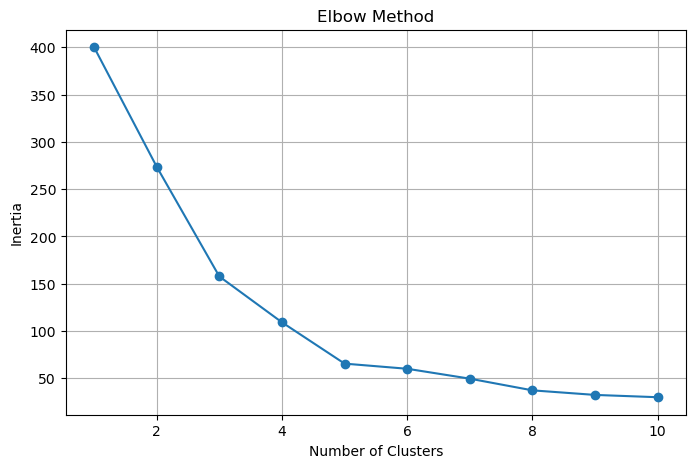

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [6]:
'''
Elbow Method and Final K-Means Model
'''

inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# Final Model
final_kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df["Cluster"] = final_kmeans.fit_predict(X_scaled)
print(df["Cluster"].value_counts())

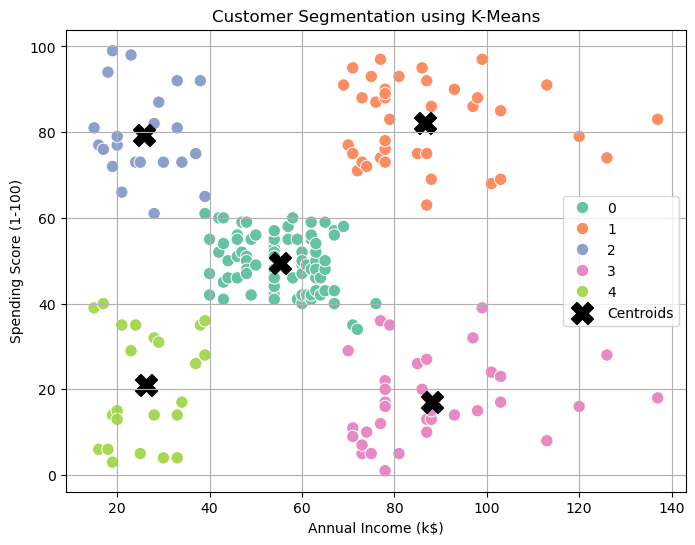

In [7]:
'''
Visualize Final Clusters
'''

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2",
    s=80
)

# Cluster Centroids
centroids = scaler.inverse_transform(final_kmeans.cluster_centers_)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c="black",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)
plt.show()